## Dust in SPT from 353GHz and 100GHz

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import healpy as hp


In [11]:
nside = 2048

lmax = 3*nside 

ell = np.arange(lmax)


### Maps and SPT mask

fsky= 0.05138632177039157


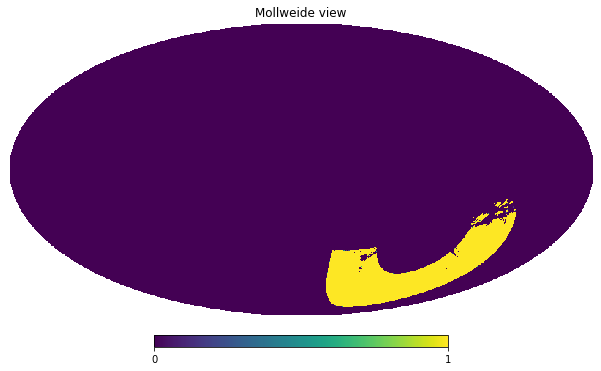

In [12]:
m353n=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_N.fits", verbose=False)
m353=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_full.fits", verbose=False)

m100=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_100_2048_R2.00_full.fits", verbose=False)
m100n=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_100_2048_R2.00_N.fits", verbose=False)



#spt=hp.read_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_Planck_min_variance_ymap_2048_partial.fits", verbose=False)

#mask = spt*0
#mask[spt >0 ] =1

#hp.mollview(mask)

maskg = hp.read_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_ingal_2048.fits", verbose=False)


#r = hp.Rotator(coord=['E','G'])
#maskg=r.rotate_map_pixel(mask)

hp.mollview(maskg)

#hp.write_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_ingal_2048.fits", maskg)

print("fsky=", np.sum(maskg)/np.size(maskg))

fsky=np.sum(maskg)/np.size(maskg)

fact = ell*(ell+1)/2/np.pi/fsky
 

## CMB spectrum

In [13]:
file="COM_PowerSpect_CMB-base-plikHM-TT-lowTEB-minimum-theory_R2.02.txt"
cmbtemp = np.genfromtxt("/Users/mdouspis/DATA/PLANCK2/"+file)
cmb=np.zeros(lmax)
ll=cmbtemp[:,0].astype("int")
cmb[ll[ll<np.max(ll)]]=cmbtemp[ll<np.max(ll),1]


## SZ spectrum 

In [14]:
tr = fits.getdata("/Users/mdouspis/SCIENCES/HillikWork/modules/data/foregrounds/tkSZ_Dl_SZDB.fits")
md_ell, sztemp = tr["ell"], tr["tSZ_Dl_mod_95x150_muK2"]


sz=sztemp[0:lmax] 

Atsz = 3.5
tszat353_143_carre = 4.64
tszat100_143_carre = 2.10

sz353 = sz/sz[3000]*Atsz*tszat353_143_carre

sz100 = sz/sz[3000]*Atsz*tszat100_143_carre


###  Maps Spectra

In [16]:

cl353  = hp.anafast(m353*maskg)
cl353n = hp.anafast(m353n*maskg)
cl100  = hp.anafast(m100*maskg)
cl100n = hp.anafast(m100n*maskg)


In [18]:
bl2_353 = hp.gauss_beam(fwhm=4.818/60.*np.pi/180.,lmax=lmax-1)**2
bl2_100 = hp.gauss_beam(fwhm=9.651/60.*np.pi/180.,lmax=lmax-1)**2


### Dust models

In [26]:
mod1 = ((ell+1e-10)/100)**(-1.2)*1e-7

mod2 = fact*((ell+1e-10)/100)**(-2.4)*1e-12

### Plot 353GHz

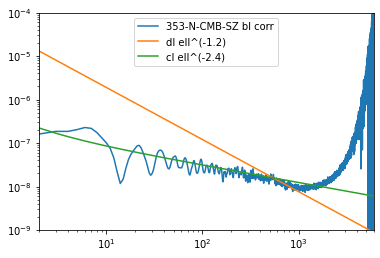

In [29]:
plt.figure()
plt.loglog(ell, fact*(cl353-cl353n)/bl2_353 - cmb*1e-12-sz353*1e-12, label="353-N-CMB-SZ bl corr")
plt.plot(ell, mod1*1.2, label="dl ell^(-1.2)")
plt.plot(ell,mod2, label="cl ell^(-2.4)")
plt.xlim(2,6000)
plt.ylim(1e-9,1e-4)

plt.legend()


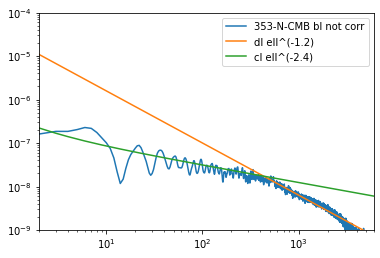

In [31]:
plt.figure()
plt.loglog(ell, fact*(cl353-cl353n) - cmb*1e-12, label="353-N-CMB bl not corr")
plt.plot(ell, mod1, label="dl ell^(-1.2)")
plt.plot(ell,mod2, label="cl ell^(-2.4)")
plt.xlim(2,6000)
plt.ylim(1e-9,1e-4)
plt.legend()


### Plot 353 and 100GHz

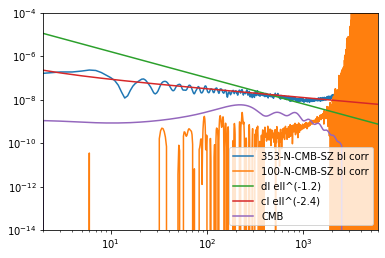

In [40]:


plt.figure()
plt.loglog(ell, fact*(cl353-cl353n)/bl2_353 - cmb*1e-12-sz353*1e-12, label="353-N-CMB-SZ bl corr")
plt.loglog(ell, fact*(cl100-cl100n)/bl2_100 - cmb*1e-12-sz100*1e-12, label="100-N-CMB-SZ bl corr")
plt.plot(ell, mod1, label="dl ell^(-1.2)")
plt.plot(ell,mod2, label="cl ell^(-2.4)")
plt.loglog(ell, cmb*1e-12, label= "CMB")
plt.xlim(2,6000)
plt.ylim(1e-14,1e-4)
plt.legend(loc=4)
